
# MScFE 632 - Group Work Project 3  
## Issue 2: Optimizing the Bias–Variance Tradeoff  



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold

plt.style.use("seaborn-v0_8-whitegrid")


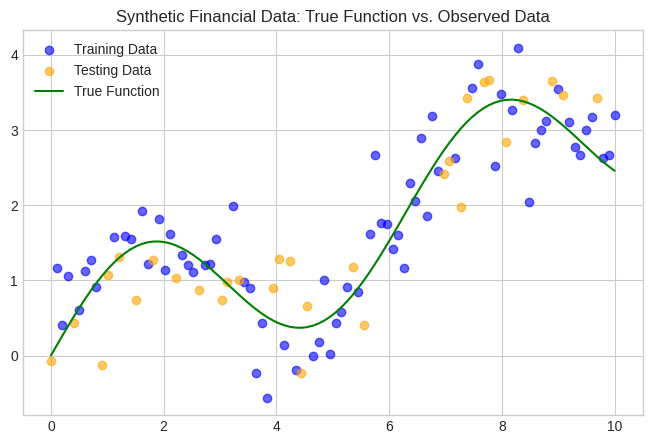

In [ ]:

# Simulated "financial" dataset: nonlinear relationship with noise
np.random.seed(99)
X = np.linspace(0, 10, 100)
y_true = np.sin(X) + 0.3 * X
y = y_true + np.random.normal(scale=0.5, size=len(X))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), y, test_size=0.3, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Training Data")
plt.scatter(X_test, y_test, color="orange", alpha=0.6, label="Testing Data")
plt.plot(X, y_true, color="green", label="True Function")
plt.title("Synthetic Financial Data: True Function vs. Observed Data")
plt.legend()
plt.show()


In [ ]:

# Function to compute bias–variance tradeoff errors
def compute_bias_variance_tradeoff(X_train, y_train, X_test, y_test, max_degree=15):
    train_errors, test_errors = [], []
    for d in range(1, max_degree + 1):
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("linreg", LinearRegression())
        ])
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        train_errors.append(mean_squared_error(y_train, y_pred_train))
        test_errors.append(mean_squared_error(y_test, y_pred_test))
    return train_errors, test_errors

train_err, test_err = compute_bias_variance_tradeoff(X_train, y_train, X_test, y_test)


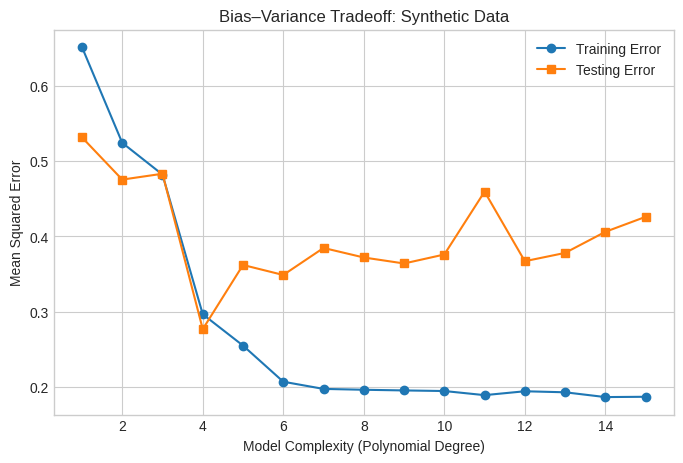

In [ ]:

# Plot bias–variance tradeoff
degrees = range(1, 16)
plt.figure(figsize=(8,5))
plt.plot(degrees, train_err, "o-", label="Training Error")
plt.plot(degrees, test_err, "s-", label="Testing Error")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias–Variance Tradeoff: Synthetic Data")
plt.legend()
plt.grid(True)
plt.show()


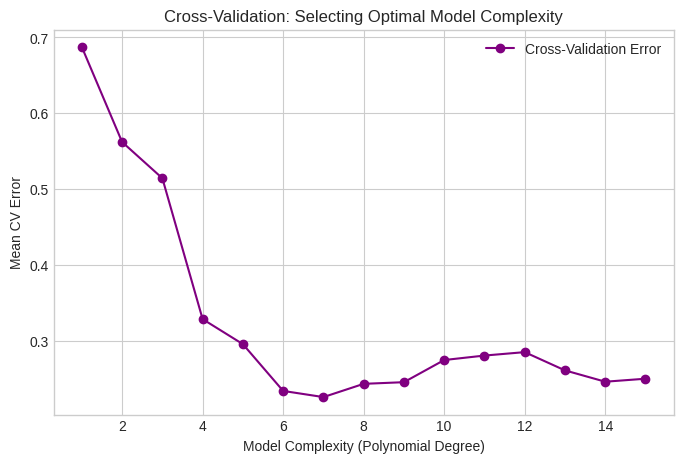

Optimal polynomial degree (min CV error): 7


In [ ]:

# Cross-validation for optimal degree
cv = KFold(n_splits=5, shuffle=True, random_state=42)
mean_cv_errors = []

for d in range(1, 16):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=cv)
    mean_cv_errors.append(-scores.mean())

plt.figure(figsize=(8,5))
plt.plot(range(1, 16), mean_cv_errors, "o-", color="purple", label="Cross-Validation Error")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean CV Error")
plt.title("Cross-Validation: Selecting Optimal Model Complexity")
plt.legend()
plt.grid(True)
plt.show()

optimal_degree = np.argmin(mean_cv_errors) + 1
print(f"Optimal polynomial degree (min CV error): {optimal_degree}")


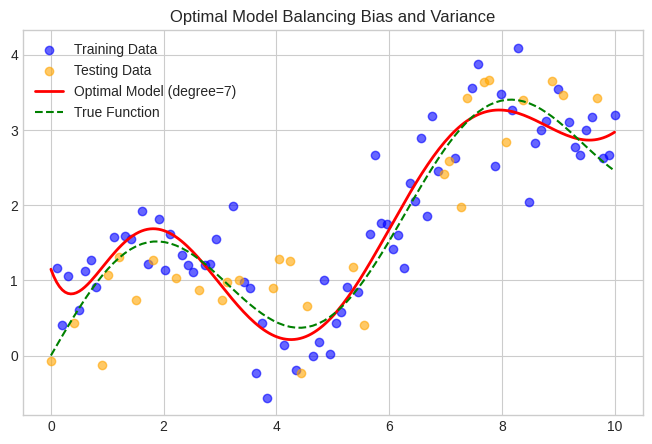

In [ ]:

# Fit and visualize optimal model
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=optimal_degree, include_bias=False)),
    ("linreg", LinearRegression())
])
best_model.fit(X_train, y_train)

X_sorted = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred_best = best_model.predict(X_sorted)

plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Training Data")
plt.scatter(X_test, y_test, color="orange", alpha=0.6, label="Testing Data")
plt.plot(X_sorted, y_pred_best, color="red", linewidth=2, label=f"Optimal Model (degree={optimal_degree})")
plt.plot(X, y_true, color="green", linestyle="--", label="True Function")
plt.title("Optimal Model Balancing Bias and Variance")
plt.legend()
plt.show()



### Interpretation

- **Underfitting (High Bias):** Low-degree models (e.g., degree 1–2) are too simple to capture the nonlinear relationship.  
- **Overfitting (High Variance):** High-degree models (e.g., degree 10+) fit noise and perform poorly on unseen data.  
- **Optimal Tradeoff:** The degree with the lowest validation error balances bias and variance.  
- **Financial Insight:** Similar to financial models, controlling model complexity avoids overreacting to random market noise.


**Issue 3_ Applying Ensemble Learning—Bagging, Boosting, or Stacking**

Regression models to predict a continuous numeric outcome

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Ensure X is 2D
if len(X.shape) == 1:
    X = X.reshape(-1, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Base learners
base_learners = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=5)),
    ('svr', SVR())
]

# Meta-learner
meta_model = LinearRegression()

# Stacking ensemble
stack_model = StackingRegressor(estimators=base_learners, final_estimator=meta_model)
stack_model.fit(X_train, y_train)

# Evaluate
y_pred = stack_model.predict(X_test)
print("Stacking R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Stacking R²: 0.8820251786343546
MSE: 0.18969276182302117


**Gradient Boosting**

Using data/stock_prices/full_history/KLAC.csv as sample dataset
Loaded 10897 rows and 7 columns.
         date  volume        open        high         low       close  \
0  2023-12-28  514100  597.099976  597.429993  585.979980  586.270020   
1  2023-12-27  586900  594.169983  594.890015  588.440002  591.469971   
2  2023-12-26  654700  586.900024  593.909973  586.169983  591.369995   
3  2023-12-22  409600  579.700012  585.000000  578.460022  582.650024   
4  2023-12-21  640400  575.500000  582.150024  572.520020  580.450012   

    adj close  
0  586.270020  
1  591.469971  
2  591.369995  
3  582.650024  
4  580.450012  

Gradient Boosting Accuracy: 0.5193

Confusion Matrix:
 [[931 445]
 [602 200]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.68      0.64      1376
           1       0.31      0.25      0.28       802

    accuracy                           0.52      2178
   macro avg       0.46      0.46      0.46   

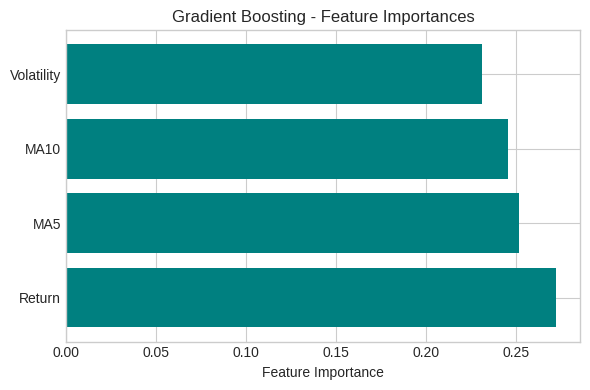

In [ ]:
# ============================================
# GRADIENT BOOSTING MODEL ON FNSPID DATASET
# ============================================

import os
import glob
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from urllib.request import urlretrieve

# --------------------------------------------
# Step 1: Download data
# --------------------------------------------

os.makedirs("data", exist_ok=True)

# Stock price data (zipped)
price_zip = "data/full_history.zip"
if not os.path.exists(price_zip):
    urlretrieve(
        "https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_price/full_history.zip",
        price_zip
    )

# Stock news data (CSV)
news_csv = "data/nasdaq_exteral_data.csv"
if not os.path.exists(news_csv):
    urlretrieve(
        "https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv",
        news_csv
    )

# --------------------------------------------
# Step 2 (Improved): Load a valid stock price CSV recursively
# --------------------------------------------

# Extract all files
with zipfile.ZipFile(price_zip, 'r') as zip_ref:
    zip_ref.extractall("data/stock_prices")

# Find all CSV files in any subfolder
csv_files = glob.glob("data/stock_prices/**/*.csv", recursive=True)

if not csv_files:
    raise FileNotFoundError("No CSV files found in extracted stock price data.")

# Pick the first one (e.g., AAPL.csv or similar)
sample_file = csv_files[0]
print(f"Using {sample_file} as sample dataset")

# Load CSV
df = pd.read_csv(sample_file)
print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")
print(df.head())

# --------------------------------------------
# Step 3: Feature Engineering
# --------------------------------------------

# Create features: moving averages and daily returns
df["Return"] = df["close"].pct_change()
df["MA5"] = df["close"].rolling(window=5).mean()
df["MA10"] = df["close"].rolling(window=10).mean()
df["Volatility"] = df["Return"].rolling(window=10).std()

# Target: 1 if price increases next day, 0 otherwise
df["Target"] = (df["close"].shift(-1) > df["close"]).astype(int)

# Drop missing rows
df.dropna(inplace=True)

# Select features and target
X = df[["Return", "MA5", "MA10", "Volatility"]]
y = df["Target"]

# --------------------------------------------
# Step 4: Train-Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# --------------------------------------------
# Step 5: Train Gradient Boosting Model
# --------------------------------------------

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

# --------------------------------------------
# Step 6: Evaluate Model
# --------------------------------------------

y_pred = gb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("\nGradient Boosting Accuracy:", round(acc, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --------------------------------------------
# Step 7: Visualize Feature Importances
# --------------------------------------------

importances = gb.feature_importances_
features = X.columns

plt.figure(figsize=(6, 4))
plt.barh(features, importances, color='teal')
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting - Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import os

# -------------------------------
# 1. Load Stock Price Data
# -------------------------------
price_path = "data/stock_prices/full_history/KLAC.csv"
price_df = pd.read_csv(price_path)

# Clean column names
price_df.columns = [c.lower().strip() for c in price_df.columns]

# Create engineered features
price_df["return"] = price_df["close"].pct_change()
price_df["volatility"] = (price_df["high"] - price_df["low"]) / price_df["open"]
price_df["target"] = price_df["close"].shift(-1)  # next day's close
price_df["date"] = pd.to_datetime(price_df["date"])
price_df = price_df.dropna()

# -------------------------------
# 2. Load News Sentiment Data
# -------------------------------
news_path = "data/nasdaq_exteral_data.csv"
news_df = pd.read_csv(news_path)

# Inspect and normalize columns
news_df.columns = [c.lower().strip() for c in news_df.columns]
print("News columns:", news_df.columns.tolist())

# Convert date column to datetime (adjust if name differs)
if "date" not in news_df.columns:
    raise ValueError("Could not find 'date' column in news dataset.")

news_df["date"] = pd.to_datetime(news_df["date"])

# If the file contains multiple tickers, filter for KLAC
if "ticker" in news_df.columns:
    news_df = news_df[news_df["ticker"].str.upper() == "KLAC"]

# Aggregate daily sentiment (mean sentiment per date)
sentiment_cols = [c for c in news_df.columns if "sent" in c or "polarity" in c]
if not sentiment_cols:
    raise ValueError("No sentiment columns found in the news dataset.")
news_daily = news_df.groupby("date")[sentiment_cols].mean().reset_index()

# -------------------------------
# 3. Merge Price + Sentiment Data
# -------------------------------
merged = pd.merge(price_df, news_daily, on="date", how="inner")

print(f"Merged dataset: {merged.shape[0]} rows, {merged.shape[1]} columns")
print("Sample merged columns:", merged.columns.tolist())

# -------------------------------
# 4. Model Training
# -------------------------------
# Define feature set (price + sentiment)
price_features = ["open", "high", "low", "volume", "return", "volatility"]
X = merged[price_features + sentiment_cols]
y = merged["target"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Gradient Boosting model
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)

# Evaluate
y_pred = gb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Hybrid Model RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# -------------------------------
# 5. Insights
# -------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", linewidth=2)
plt.plot(y_pred[:100], label="Predicted", linewidth=2)
plt.title("Hybrid Gradient Boosting Model — Actual vs. Predicted (KLAC)")
plt.xlabel("Test Sample Index")
plt.ylabel("Next-Day Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**FOOTNOTE**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.